In [21]:
# Install necessary packages
!pip install huggingface_hub
!pip install transformers
!pip install datasets

In [22]:

# Relevant imports
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from datasets import Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch


In [23]:
# Load data
df = pd.read_csv('Extended_Course_Feedback_Dataset.csv')

In [24]:
df.shape

(2000, 2)

In [25]:
df.head()

,COMMENT,LABEL
0,"""This course exceeded my expectations in every...",very positive
1,"""The instructor was incredibly knowledgeable a...",very positive
2,"""I learned so much and feel very confident in ...",very positive
3,"""The course materials were comprehensive and e...",very positive
4,"""The interactive sessions made learning fun an...",very positive


In [26]:
df.value_counts('LABEL')

,count
LABEL,
very negative,536
negative,485
very positive,339
neutral,336
positive,304


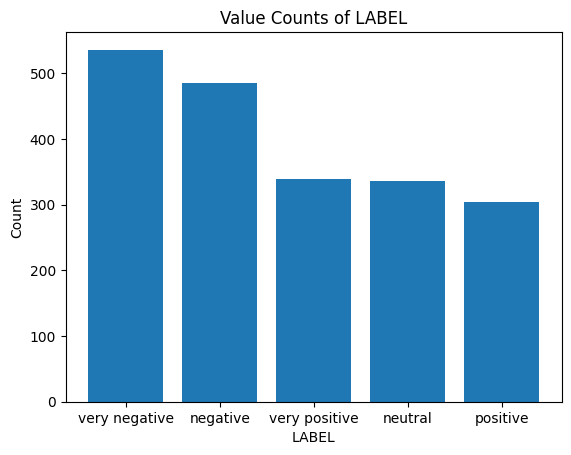

In [27]:
plt.bar(df['LABEL'].value_counts().index, df['LABEL'].value_counts().values) # Call the bar function directly from plt
plt.xlabel('LABEL')
plt.ylabel('Count')
plt.title('Value Counts of LABEL')
plt.show()

In [28]:
# Replacing text labels with numerical values
label_mapping = {
    'very positive': 5,
    'positive': 4,
    'neutral': 3,
    'negative': 2,
    'very negative': 1
}

In [29]:
df['LABEL'].replace(label_mapping, inplace=True)

/tmp/ipython-input-2606929845.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LABEL'].replace(label_mapping, inplace=True)
/tmp/ipython-input-2606929845.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['LABEL'].replace(label_mapping, inplace=True)


In [30]:
df['LABEL'] = df['LABEL'] - 1

In [31]:
# Renaming columns
df = df.rename(columns={'COMMENT': 'text', 'LABEL': 'labels'})

In [32]:
# Splitting data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(df['text'], df['labels'], test_size=0.25, random_state=42)

In [33]:
# Preparing the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [34]:
# Tokenizing the data
train_encodings = tokenizer(x_train.tolist(), truncation=True, padding=True, max_length=512)
test_encodings = tokenizer(x_test.tolist(), truncation=True, padding=True, max_length=512)

In [35]:
list(train_encodings.keys())

['input_ids', 'token_type_ids', 'attention_mask']

In [36]:
# Converting the data into datasets for the trainer
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': y_train.tolist()
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': y_test.tolist()
})

In [37]:
# Loading the model
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=5)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:01<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [40]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=10,
)

In [41]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


In [42]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics = compute_metrics
)

In [43]:
# Training
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,1.693881
20,1.651910
30,1.601835
40,1.598882
50,1.506597
60,1.460733
70,1.405164
80,1.417700
90,1.362492
100,1.277554


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=564, training_loss=0.5048948028455125, metrics={'train_runtime': 952.4545, 'train_samples_per_second': 4.725, 'train_steps_per_second': 0.592, 'total_flos': 43938674181000.0, 'train_loss': 0.5048948028455125, 'epoch': 3.0})

In [44]:
results = trainer.evaluate(eval_dataset=test_dataset)
print(f"Accuracy: {results['eval_accuracy']}")
print(f"Precision: {results['eval_precision']}")
print(f"Recall: {results['eval_recall']}")
print(f"F1 Score: {results['eval_f1']}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.976
Precision: 0.9761855136866481
Recall: 0.976
F1 Score: 0.9760237450346472


In [45]:
predictions, labels, _ = trainer.predict(test_dataset)
preds = np.argmax(predictions, axis = 1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


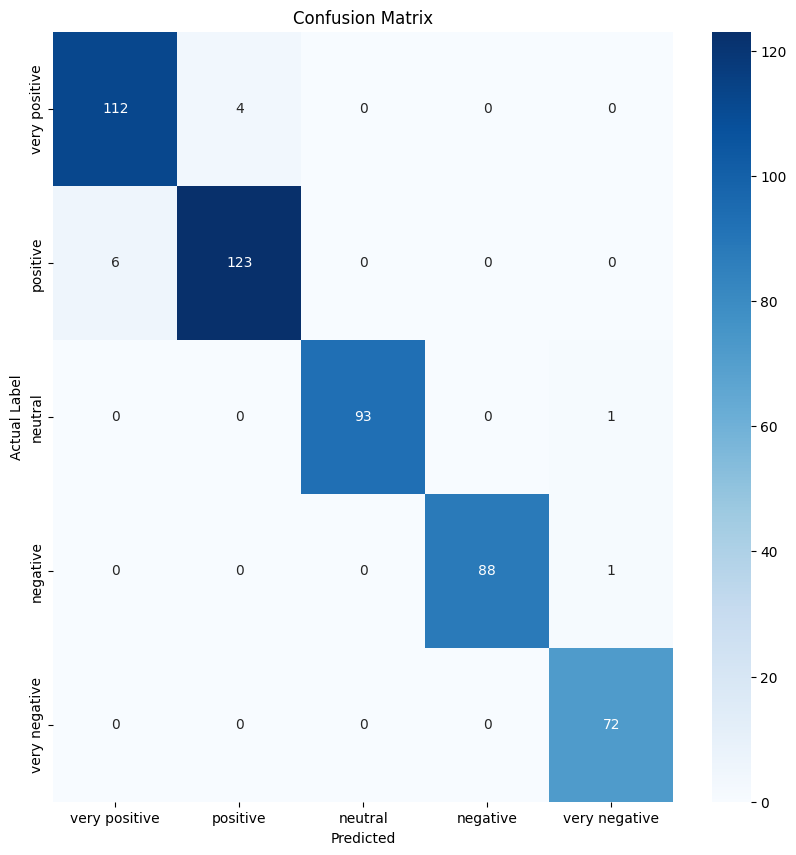

In [46]:
plt.figure(figsize=(10, 10))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt ='d', cmap='Blues',xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual Label')
plt.show()

In [47]:
model.save_pretrained('/content/model')
tokenizer.save_pretrained('/content/tokenizer')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/tokenizer/tokenizer_config.json',
 '/content/tokenizer/tokenizer.json')

In [48]:
def predict_sentiment(comment: str):
    # Tokenize the input comment
    inputs = tokenizer(comment, return_tensors="pt", truncation=True, padding=True, max_length=512)

    # Get model predictions
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    # Get the label with the highest probability
    predicted_label = torch.argmax(logits, dim=1).item()

    # Map the predicted label to the sentiment
    label_mapping = {0: 'very negative', 1: 'negative', 2: 'neutral', 3: 'positive', 4: 'very positive'}
    sentiment = label_mapping.get(predicted_label, "Unknown")

    return sentiment


In [53]:
comment = input("Enter a comment: ")
predicted_sentiment = predict_sentiment(comment)
print(f"Predicted Sentiment: {predicted_sentiment}")

Enter a comment: a fantastic class
Predicted Sentiment: very positive
